# El Perceptrón y las Funciones de Activación: La Unidad Básica del Deep Learning

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/04_deep_learning/01_perceptron_y_activaciones.ipynb)

## Objetivos


- Comprender la **neurona artificial** como la unidad computacional básica del Deep Learning.
- Demostrar matemáticamente por qué la **no linealidad** es un requisito absoluto para resolver problemas complejos (como el XOR).
- Analizar el catálogo de **Funciones de Activación** (Sigmoide, Tanh, ReLU, GELU) desde una perspectiva de ingeniería: sus derivadas, ventajas y fallos catastróficos.
- **Experimento de Ingeniería:** Utilizar `tf.GradientTape` para visualizar el problema del *Vanishing Gradient* (Gradiente Desvaneciente) y entender por qué ReLU se convirtió en el estándar de la industria.

## Prerrequisitos


- Entendimiento de la Regresión Logística y el Descenso del Gradiente.
- Haber completado el Capítulo 3 (Machine Learning Clásico).

---



## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
setup_plot_style()

# Importamos TensorFlow
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


# Reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow versión: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

TensorFlow versión: 2.20.0
GPU disponible: []


## 1. Introducción: De la Regresión Logística a la Neurona



En el Capítulo 3, aprendimos que la Regresión Logística calcula una suma ponderada de las entradas y luego pasa ese resultado por una función Sigmoide para aplastarlo entre 0 y 1.

Sorprendentemente, **acabamos de describir exactamente lo que hace una neurona artificial**.

Matemáticamente, una neurona realiza dos operaciones secuenciales:
1. **Transformación Lineal:** $z = \mathbf{w} \cdot \mathbf{x} + b$ (donde $\mathbf{w}$ son los pesos, $\mathbf{x}$ las entradas y $b$ el sesgo o *bias*).
2. **Transformación No Lineal:** $a = \phi(z)$ (donde $\phi$ es la **Función de Activación**).

El Deep Learning moderno no es más que la composición inteligente de miles o millones de estas unidades básicas, organizadas en capas, optimizadas mediante el cálculo de derivadas (Backpropagation).



### 🧠 Herramienta Interactiva: TensorFlow Playground


Antes de entrar en el código y cosas complejas, recomiendo encarecidamente abrir el [TensorFlow Playground](https://playground.tensorflow.org/). Es una herramienta visual desarrollada por Google que permite construir redes neuronales simples en el navegador. Muchos de los conceptos pueden "probarse" y "entenderse" de manera empírica a partir de analizar el funcionamiento y los resultados.  

> *Ejercicio sugerido:* Intentar resolver el problema del "Espiral" usando solo activaciones "Lineales". ¿Es posible o imposible?. Luego, cambiar a "ReLU" y observar "la magia".

**NOTA**: En cualquiera de los casos... es posible que NO se llegue a un buen resultado "rápido", intentar de entender la conformación de la arquitectura "ideal" con los problemas más simples primero.

## 2. ¿Por qué necesitamos Funciones de Activación?


Si la transformación lineal ($z = \mathbf{w} \cdot \mathbf{x} + b$) ya hace el trabajo pesado, ¿por qué complicamos el cálculo pasándolo por una función $\phi(z)$?

**"Demostración" Matemática:**  
Imaginemos una red neuronal de 3 capas *sin* funciones de activación (es decir, $\phi(z) = z$).
- Capa 1: $h_1 = W_1 \cdot x$
- Capa 2: $h_2 = W_2 \cdot h_1$
- Capa 3 (Salida): $y = W_3 \cdot h_2$

Si sustituimos las ecuaciones:
$$ y = W_3 \cdot (W_2 \cdot (W_1 \cdot x)) = (W_3 \cdot W_2 \cdot W_1) \cdot x $$  

Como la multiplicación de matrices es asociativa, $(W_3 \cdot W_2 \cdot W_1)$ se colapsa en una sola matriz $W_{final}$.   

**Conclusión:** Una red neuronal de `1.000` capas sin funciones de activación no lineales es matemáticamente equivalente a una simple Regresión Lineal. No importa qué tan profunda sea la red, jamás podrá resolver un problema que no se pueda separar con una línea recta (como el problema XOR).

## 3. El Catálogo de Activaciones (Criterio de Ingeniería)



A lo largo de las décadas, la industria ha evolucionado buscando la función de activación perfecta. Vamos a visualizar las más importantes y sus **derivadas**.

*Nota de Ingeniería:* La derivada es crítica. Durante el entrenamiento (*Backpropagation*), el error viaja hacia atrás multiplicándose por la derivada de la función de activación. Si la derivada es cero, la red deja de aprender.

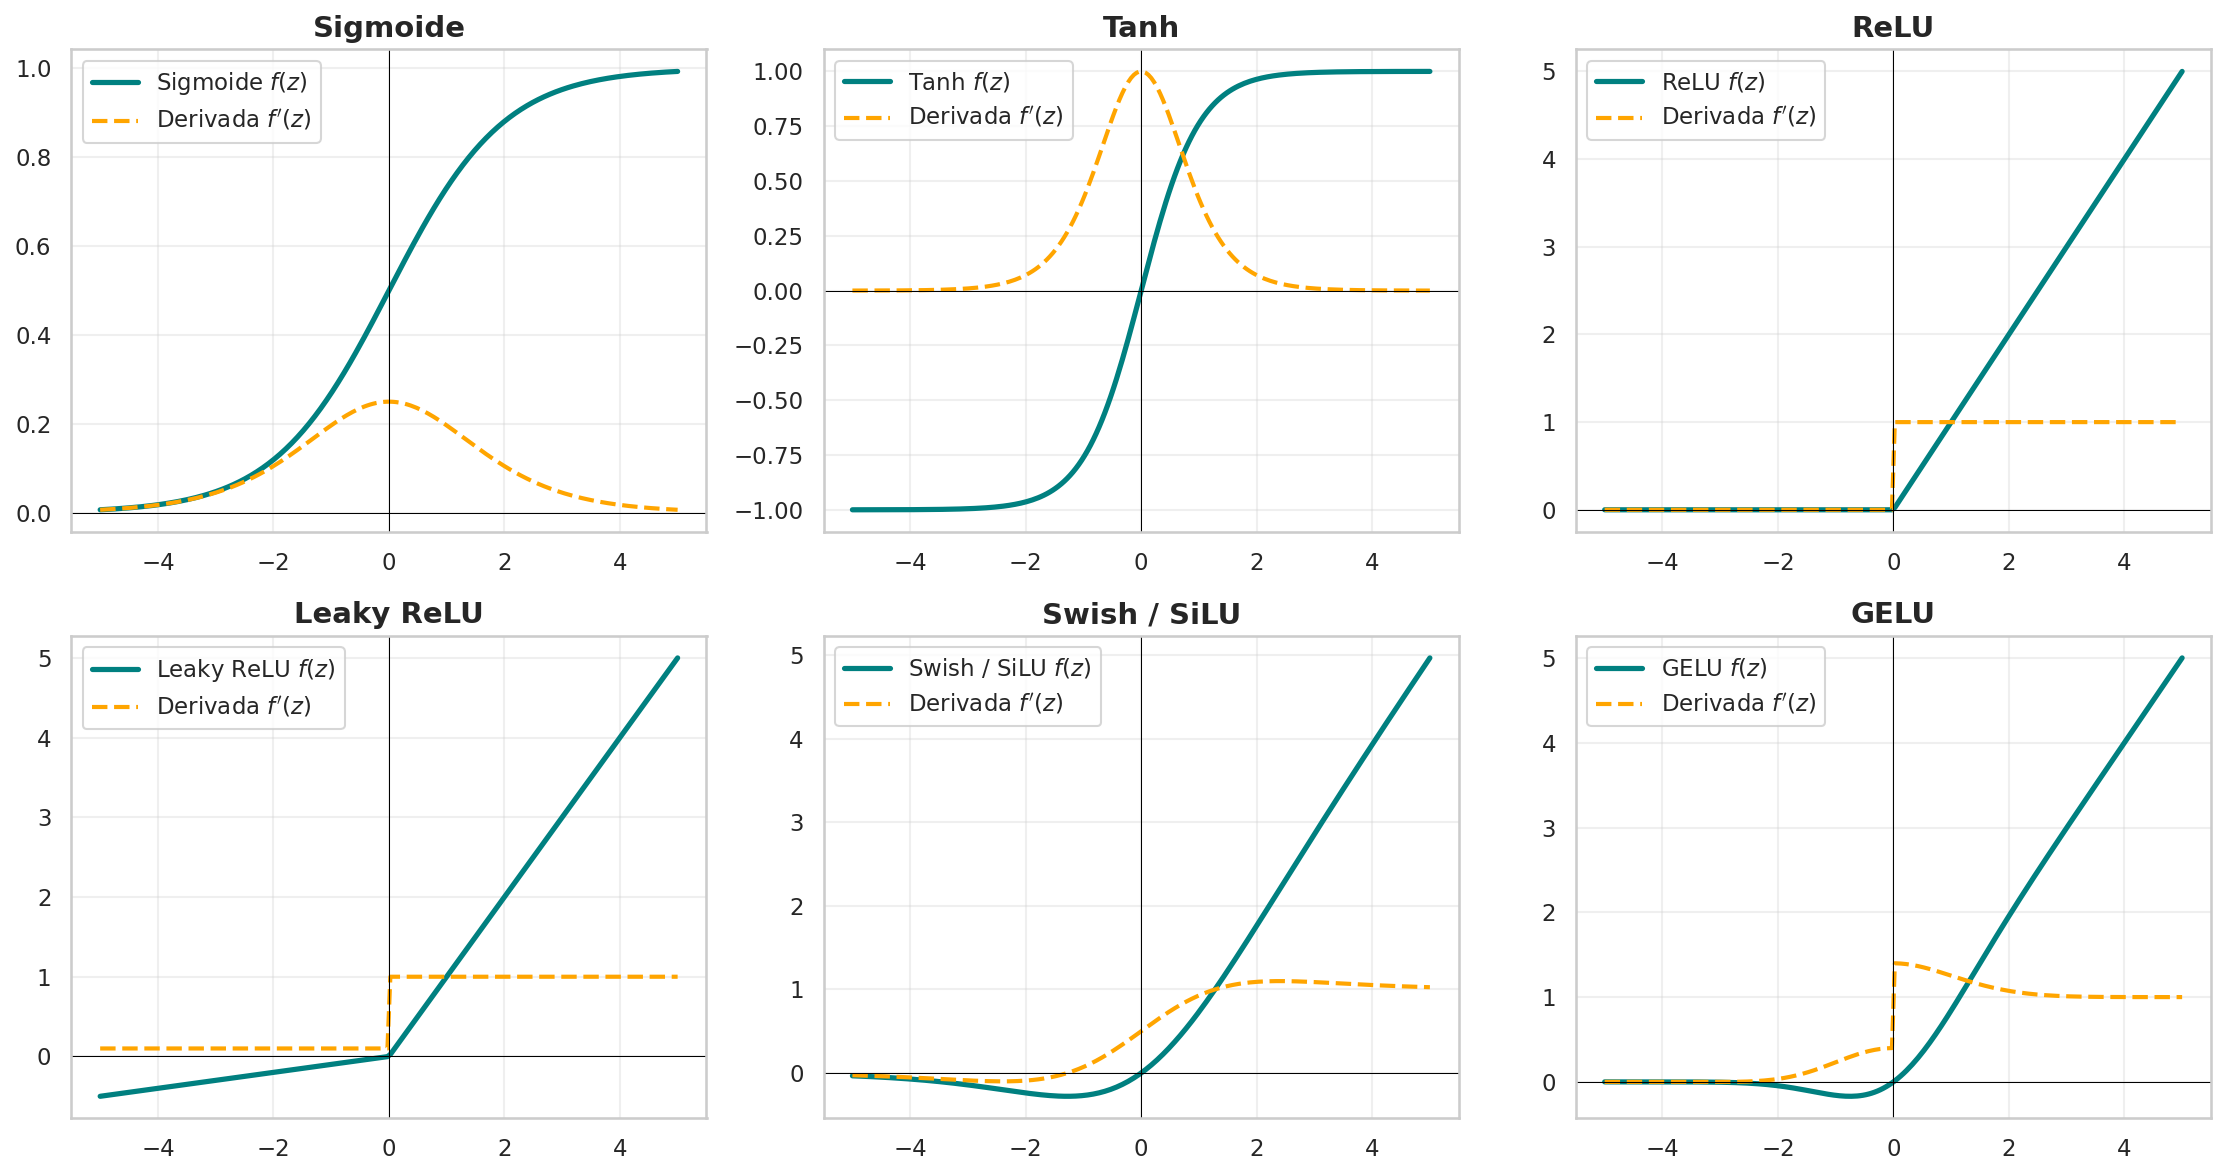

In [6]:
# Definimos el rango de entrada (z)
z = np.linspace(-5, 5, 200)
z = tf.constant(z, dtype=tf.float32)

# Definimos las funciones y sus derivadas usando TensorFlow
activaciones = {
    'Sigmoide': (tf.nn.sigmoid(z), tf.nn.sigmoid(z) * (1 - tf.nn.sigmoid(z))),
    'Tanh': (tf.nn.tanh(z), 1 - tf.square(tf.nn.tanh(z))),
    'ReLU': (tf.nn.relu(z), tf.where(z > 0, 1.0, 0.0)),
    'Leaky ReLU': (tf.nn.leaky_relu(z, alpha=0.1), tf.where(z > 0, 1.0, 0.1)),
    'Swish / SiLU': (tf.nn.silu(z), tf.nn.silu(z) + tf.nn.sigmoid(z) * (1 - tf.nn.silu(z))),
    'GELU':    (tf.nn.gelu(z),
                # Derivada aproximada de GELU (suficiente para visualización)
                tf.cast(z > 0, tf.float32) +
                tf.exp(-0.5 * z**2) / tf.sqrt(2 * np.pi) *
                (1 + 0.044715 * z**3))
}

# Visualización
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (nombre, (f_z, df_z)) in enumerate(activaciones.items()):
    ax = axes[i]
    ax.plot(z, f_z, label=f'{nombre} $f(z)$', color='teal', linewidth=2.5)
    ax.plot(z, df_z, label=f'Derivada $f\'(z)$', color='orange', linestyle='--', linewidth=2)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_title(nombre, fontsize=14)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Tabla de Decisión (Estándar 2026)



| Función | Rango de Salida | Ventajas | Desventajas | Uso Recomendado |
| :--- | :--- | :--- | :--- | :--- |
| **Sigmoide** | $(0, 1)$ | Salida probabilística. | **Vanishing Gradient** (Derivada máxima es 0.25). Costosa. | **Capa de salida** (Clasificación Binaria). Jamás en capas ocultas. |
| **Tanh** | $(-1, 1)$ | Centrada en cero (facilita optimización). | **Vanishing Gradient** en los extremos. | RNNs antiguas. Rara vez en ML moderno. |
| **ReLU** | $[0, \infty)$ | Computacionalmente gratis. Derivada = 1 (No desvanece). | **Dying ReLU** (Neuronas muertas si $z < 0$). | **Estándar absoluto** para capas ocultas en CNNs y MLPs. |
| **Leaky ReLU** | $(-\infty, \infty)$ | Evita la muerte de neuronas (derivada pequeña si $z < 0$). | Añade un hiperparámetro extra ($\alpha$). | Alternativa robusta a ReLU. Cuando se observan neuronas muertas. |
| **Swish** | $(-\infty, \infty)$ | Suave, excelente performance. | Computacionalmente más costosa que ReLU. | Modelos medianos. |
| **GELU** | $(-\infty, \infty)$ | Suavizado probabilístico, muy estable. | Computacionalmente más costosa que ReLU. | **Estado del Arte** en LLMs (Transformers, BERT, GPT). |


## 4. Experimento de Ingeniería: El "*Vanishing Gradient*"



Antes de 2010, las redes neuronales profundas eran consideradas un fracaso. Nadie podía entrenar una red de más de 3 o 4 capas. ¿El culpable? La función **Sigmoide**.

Observar el gráfico de la derivada de la Sigmoide (línea naranja). Su valor máximo es **0.25**.
Durante el *Backpropagation*, el gradiente (la señal de aprendizaje) se multiplica por esta derivada en cada capa hacia atrás.
Si se tienen 10 capas, el gradiente de la primera capa se multiplicará por $0.25^{10} \approx 0.0000009$. **La señal de aprendizaje desaparece.** Las primeras capas de la red jamás se actualizan.

Vamos a demostrar esto empíricamente construyendo dos redes de 10 capas y midiendo la fuerza del gradiente en la primera capa usando `tf.GradientTape` (el motor de diferenciación automática de TensorFlow).

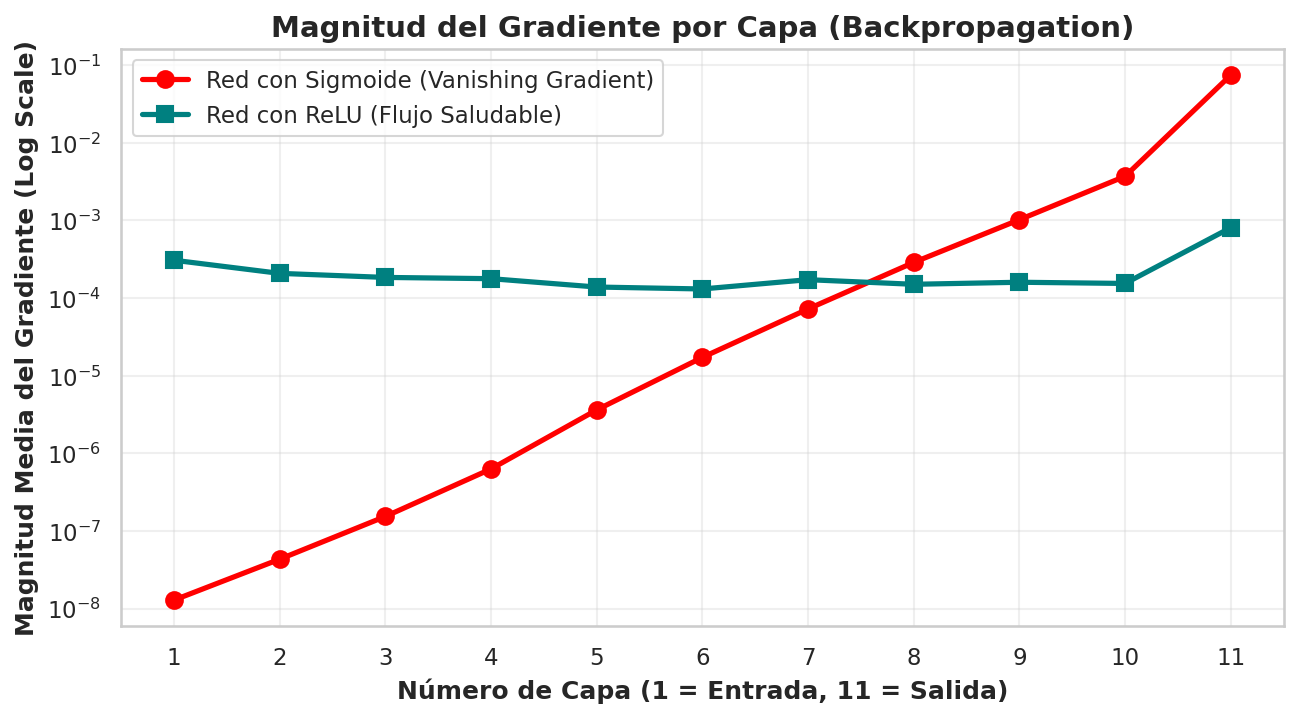

In [4]:
# 1. Creamos datos de juguete
X_dummy = tf.random.normal((32, 10)) # Batch de 32, 10 features
y_dummy = tf.random.uniform((32, 1), minval=0, maxval=2, dtype=tf.int32)
y_dummy = tf.cast(y_dummy, tf.float32)

# 2. Función para construir una red profunda y extraer los gradientes
def obtener_gradientes_por_capa(activacion):
    # Construimos un modelo de 10 capas ocultas
    modelo = tf.keras.Sequential()
    modelo.add(tf.keras.layers.InputLayer(shape=(10,)))
    for _ in range(10):
        # Usamos inicialización estándar para aislar el efecto de la activación
        modelo.add(tf.keras.layers.Dense(32, activation=activacion, kernel_initializer='glorot_normal'))
    modelo.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    # Función de pérdida
    loss_fn = tf.keras.losses.BinaryCrossentropy()

    # GradientTape graba las operaciones para calcular derivadas
    with tf.GradientTape() as tape:
        predicciones = modelo(X_dummy)
        loss = loss_fn(y_dummy, predicciones)

    # Calculamos los gradientes de la pérdida respecto a los pesos de cada capa
    gradientes = tape.gradient(loss, modelo.trainable_variables)

    # Extraemos la magnitud media absoluta del gradiente para los pesos (W) de cada capa
    magnitudes =[tf.reduce_mean(tf.abs(g)).numpy() for g in gradientes[::2]] # [::2] toma solo los W, ignora los bias
    return magnitudes

# 3. Ejecutamos el experimento
gradientes_sigmoide = obtener_gradientes_por_capa('sigmoid')
gradientes_relu = obtener_gradientes_por_capa('relu')

# 4. Visualizamos el desastre
capas = np.arange(1, 12) # 10 ocultas + 1 salida

plt.figure(figsize=(10, 5))
plt.plot(capas, gradientes_sigmoide, marker='o', color='red', label='Red con Sigmoide (Vanishing Gradient)')
plt.plot(capas, gradientes_relu, marker='s', color='teal', label='Red con ReLU (Flujo Saludable)')

plt.title("Magnitud del Gradiente por Capa (Backpropagation)", fontsize=14)
plt.xlabel("Número de Capa (1 = Entrada, 11 = Salida)")
plt.ylabel("Magnitud Media del Gradiente (Log Scale)")
plt.yscale('log') # Escala logarítmica para "ver" la diferencia, es masiva
plt.xticks(capas)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Análisis: Leyendo el Gráfico


Observar el eje X. El error se calcula en la Capa 11 (Salida) y viaja hacia atrás hasta la Capa 1 (Entrada).
- **Red con Sigmoide (Línea Roja):** En la capa 11, el gradiente es fuerte. Pero a medida que viaja hacia atrás, se multiplica por números menores a 0.25. Al llegar a la Capa 1, el gradiente es de $10^{-8}$. **Las primeras capas están "congeladas" y no aprenden nada.**
- **Red con ReLU (Línea Verde):** Como la derivada de ReLU es exactamente 1 (si $z>0$), el gradiente fluye libremente hacia atrás sin atenuarse. La Capa 1 recibe una señal de aprendizaje fuerte y clara.

**Conclusión de Ingeniería:** ReLU salvó al Deep Learning. Permitió entrenar redes de cientos de capas (como ResNet) sin que el gradiente desapareciera.

## 5. El Lado Oscuro de ReLU: "*Dying ReLU*"


Si ReLU es tan buena, ¿por qué existen Leaky ReLU o GELU?

Observar de nuevo el gráfico de la derivada de ReLU en la Sección 3. Si la entrada $z$ es menor a cero, **la derivada es exactamente `0.0`**.
Si durante el entrenamiento, una actualización de pesos empuja a una neurona a un estado donde siempre produce $z < 0$ para todos los datos del dataset, esa neurona emitirá un gradiente de `0`. **La neurona ha muerto.** Nunca más se actualizará, convirtiéndose en un peso muerto en la memoria de la GPU.

Si se inicializan mal los pesos de una red, o se usa un *Learning Rate* demasiado alto, podemos, por ejemplo; matar al 50% de las neuronas de la red en la primera época.

## Conexiones y Próximos Pasos


Descubrimos que la elección de la función de activación dicta si una red puede aprender o si colapsará matemáticamente. Sin embargo, en nuestro experimento de *Vanishing Gradient*, hicimos trampa: usamos una inicialización de pesos estándar (`glorot_normal`).

Resulta que **la función de activación y la inicialización de los pesos son dos caras de la misma moneda**. Si se usa ReLU con la inicialización incorrecta, la red explotará.

- ➡️ **Siguiente:** En el notebook [Inicialización y Redes Profundas](02_inicializacion_y_redes_profundas.ipynb), aprendemos a construir un Perceptrón Multicapa (MLP) estable. Descubrimos por qué inicializar los pesos en ceros es el peor error posible, y cómo la inicialización **He Normal** fue diseñada específicamente para salvar a las redes basadas en ReLU.

## Referencias

**y lecturas recomendadas...**

### Artículos Fundacionales
1. **Glorot, X., & Bengio, Y. (2010)**. *Understanding the difficulty of training deep feedforward neural networks*. Proceedings of the Thirteenth International Conference on Artificial Intelligence and Statistics (AISTATS).  
   [[PDF]](https://proceedings.mlr.press/v9/glorot10a/glorot10a.pdf)

2. **Krizhevsky, A., Sutskever, I., & Hinton, G. E. (2012)**. *ImageNet Classification with Deep Convolutional Neural Networks*. Advances in Neural Information Processing Systems (NeurIPS).  
   (Paper que popularizó masivamente el uso de **ReLU**).  
   [[PDF]](https://proceedings.neurips.cc/paper_files/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf)

3. **Hendrycks, D., & Gimpel, K. (2016)**. *Gaussian Error Linear Units (GELUs)*. arXiv preprint arXiv:1606.08415.  
   (Activación utilizada en BERT, GPT, ViT, etc.).  
   [[arXiv]](https://arxiv.org/abs/1606.08415)

### Recursos Interactivos y Pedagógicos
- [TensorFlow Playground](https://playground.tensorflow.org/) – Google (herramienta visual excelente).
- Serie de videos **Neural Networks** de 3Blue1Brown (Grant Sanderson) – Altamente recomendada.
- Capítulo 6 del libro *Deep Learning* (Goodfellow, Bengio, Courville) – Disponible gratis online.

### Otras referencias técnicas
- Ioffe, S., & Szegedy, C. (2015). *Batch Normalization* (lo mencionado como solución futura al *vanishing gradient*).
- He, K. et al. (2015). *Delving Deep into Rectifiers* (paper de He Initialization + ReLU).

---


## Entorno de Ejecución


In [13]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.13
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
keras,3.13.2
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
